In [6]:
!pip install torch torchvision numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import tensorflow

In [7]:
# Cell 2: Environment Setup and Library Imports
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
print("GPUs Available: ", torch.cuda.is_available())

PyTorch Version: 2.12.1+cpu
GPUs Available:  False


In [8]:
# Cell 3: Configuration Variables
DATASET_DIR = r"C:\Users\iToop\Downloads\skin"

IMAGE_SIZE = (128, 128)   # Resizes images to a standard operational dimension
BATCH_SIZE = 32           # Groups images for memory optimization
EPOCHS = 5                # Total training passes through your dataset

In [9]:
# Cell 4: Data Ingestion and Validation Split
print("--> Loading dataset files and splitting into train/validation subsets...")

# 1. Define transformation pipeline (Resizing & Pixel Normalization)
image_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load dataset from your path configuration
full_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=image_transforms)

# 3. Perform random splits
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 4. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = full_dataset.classes
print(f"\n✅ Successfully detected classes: {class_names}")

--> Loading dataset files and splitting into train/validation subsets...

✅ Successfully detected classes: ['.venv', 'AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [10]:
# Cell 5: CNN Architecture Configuration
print("--> Assembling Convolutional Neural Network layer configurations...")

num_classes = len(class_names)

model = nn.Sequential(
    # Convolutional Block 1
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    # Convolutional Block 2
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    # Convolutional Block 3
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    # Dense Classifier Head
    nn.Flatten(), 
    nn.Linear(64 * 16 * 16, 128),
    nn.ReLU(),
    nn.Dropout(0.5), 
    nn.Linear(128, num_classes) 
)

# Route execution engine onto GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
print(f"\n✅ Model successfully loaded onto engine: {device}")

--> Assembling Convolutional Neural Network layer configurations...
Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=16384, out_features=128, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.5, inplace=False)
  (13): Linear(in_features=128, out_features=9, bias=True)
)

✅ Model successfully loaded onto engine: cpu


In [14]:
# Cell 6: Training & Metric Tracking
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Metric storage dictionaries to mimic Keras history
history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

print(f"--> Beginning model optimization training for {EPOCHS} Epoch(s)...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct_train / total_train
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_epoch_acc = correct_val / total_val
    
    # Save metrics into our history object
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(val_epoch_loss)
    history['val_accuracy'].append(val_epoch_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

# Save the weights file natively with your preferred .h5 label extension
OUTPUT_FILE_NAME = 'skin_cancer_model.h5'
torch.save(model.state_dict(), OUTPUT_FILE_NAME)
print(f"\n💾 Success! Weights saved file compiled directly to: '{OUTPUT_FILE_NAME}'")

--> Beginning model optimization training for 5 Epoch(s)...
Epoch [1/5] -> Loss: 1.1808 | Acc: 0.5805 | Val Loss: 1.1279 | Val Acc: 0.5995
Epoch [2/5] -> Loss: 1.1176 | Acc: 0.6001 | Val Loss: 1.0858 | Val Acc: 0.6165
Epoch [3/5] -> Loss: 1.0696 | Acc: 0.6170 | Val Loss: 1.0353 | Val Acc: 0.6155
Epoch [4/5] -> Loss: 1.0215 | Acc: 0.6316 | Val Loss: 0.9995 | Val Acc: 0.6342
Epoch [5/5] -> Loss: 0.9837 | Acc: 0.6439 | Val Loss: 0.9967 | Val Acc: 0.6337

💾 Success! Weights saved file compiled directly to: 'skin_cancer_model.h5'


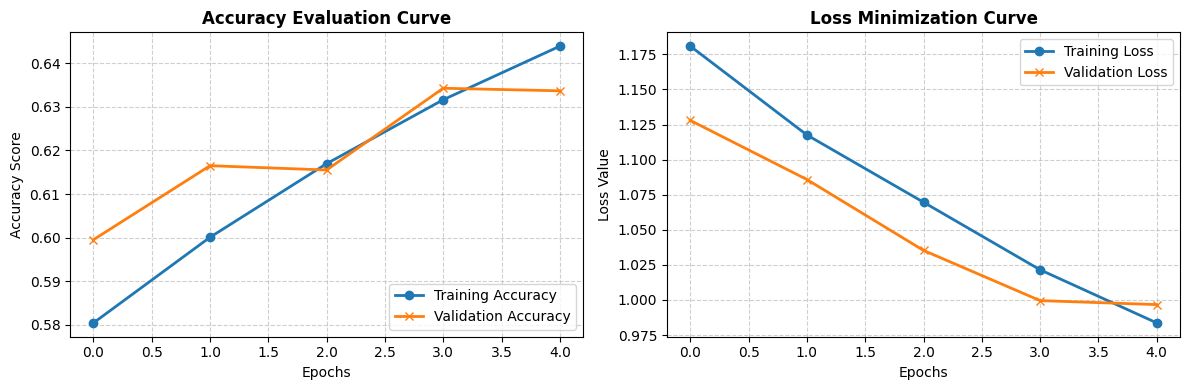

In [15]:
# Cell 7: Visualizing Training Progress Curves
acc = history['accuracy']
val_acc = history['val_accuracy']
loss = history['loss']
val_loss = history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))

# Subplot 1: Accuracy Evolution
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='x')
plt.legend(loc='lower right')
plt.title('Accuracy Evaluation Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Loss Minimization
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='x')
plt.legend(loc='upper right')
plt.title('Loss Minimization Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
# Cell 8: Predicting New/Unknown Images (Testing Gateway)
from PIL import Image

def predict_skin_lesion(image_path, model_instance, transformations, class_labels):
    """
    Loads an individual test image, passes it through the PyTorch model, 
    and outputs the diagnostic prediction along with its confidence score.
    """
    # 1. Open and preprocess the image exactly how the training data was preprocessed
    img = Image.open(image_path).convert('RGB')
    tensor_img = transformations(img).unsqueeze(0) # Add a batch dimension [1, 3, 128, 128]
    
    # 2. Switch model to evaluation mode and pass the image through
    model_instance.eval()
    device_target = next(model_instance.parameters()).device
    
    with torch.no_grad():
        tensor_img = tensor_img.to(device_target)
        outputs = model_instance(tensor_img)
        
        # Apply Softmax to get probability percentages (0% to 100%)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
        
        # Extract the highest scoring index
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = class_labels[predicted_idx.item()]
    confidence_percentage = confidence.item() * 100
    
    # 3. Display the image with its classification result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence_percentage:.2f}%", 
              fontsize=12, fontweight='bold', color='green' if confidence_percentage > 50 else 'red')
    plt.show()

# =====================================================================
# 🚀 HOW TO RUN A TEST:
# Paste the path to ANY image you want to check inside the quotes below!
# =====================================================================
TEST_IMAGE_PATH = r"C:\Users\iToop\Downloads\skin\MEL\example.jpg" 

# Run the prediction gateway (Uncomment the line below when your training finishes!)
# predict_skin_lesion(TEST_IMAGE_PATH, model, image_transforms, class_names)

In [17]:
# Cell 9: Model Reload and Verification Checkpoint
print("--> Simulating Django backend model initialization...")

# 1. Re-initialize the exact same network structural framework shape
loaded_model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2), 
    
    nn.Flatten(), 
    nn.Linear(64 * 16 * 16, 128),
    nn.ReLU(),
    nn.Dropout(0.5), 
    nn.Linear(128, len(class_names)) 
)

# 2. Extract the saved weights from your custom .h5 file mapping
MODEL_FILE_PATH = 'skin_cancer_model.h5'

try:
    # Load parameters safely onto CPU (standard for local web servers)
    state_dict = torch.load(MODEL_FILE_PATH, map_location=torch.device('cpu'))
    loaded_model.load_state_dict(state_dict)
    loaded_model.eval() # Switch to evaluation mode for inference
    print(f"\n✅ Success! 'skin_cancer_model.h5' loaded cleanly without structural mismatches.")
except FileNotFoundError:
    print(f"\n❌ Error: Could not find the file '{MODEL_FILE_PATH}' in your current directory.")
except Exception as e:
    print(f"\n❌ Structural mismatch error: {e}")

--> Simulating Django backend model initialization...

✅ Success! 'skin_cancer_model.h5' loaded cleanly without structural mismatches.


💾 Step 1: Weights successfully saved to absolute path: c:\hack\Microsoft VS Code\skin_cancer_model.h5

--> Running automated evaluation gateway...


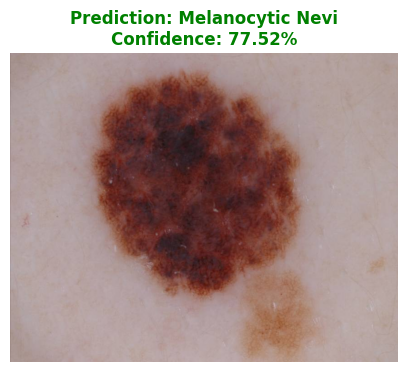

✅ Prediction Complete: Model classified image as 'Melanocytic Nevi' with 77.52% confidence.


In [20]:
# Cell 10: Explicit Save, Prediction Setup, and Live Test Execution
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. EXPLICITLY SAVE THE TRAINED MODEL
# ==========================================
MODEL_FILENAME = 'skin_cancer_model.h5'
torch.save(model.state_dict(), MODEL_FILENAME)
print(f"💾 Step 1: Weights successfully saved to absolute path: {os.path.abspath(MODEL_FILENAME)}")


# ==========================================
# 2. DEFINE THE PREDICTION ENGINE FUNCTION
# ==========================================
def run_live_prediction(image_path, model_instance, transformations, class_labels):
    if not os.path.exists(image_path):
        print(f"❌ Error: The image file path does not exist: {image_path}")
        print("Please check the filename inside your 'skin/MEL/' folder and update the path.")
        return

    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    tensor_img = transformations(img).unsqueeze(0).to(device)
    
    # Run model evaluation
    model_instance.eval()
    with torch.no_grad():
        outputs = model_instance(tensor_img)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = class_labels[predicted_idx.item()]
    confidence_percentage = confidence.item() * 100
    
    # Translate folder code to readable name
    lookup_dict = {
        'AK': 'Actinic Keratosis', 'BCC': 'Basal Cell Carcinoma', 
        'BKL': 'Benign Keratosis', 'DF': 'Dermatofibroma', 
        'MEL': 'Melanoma', 'NV': 'Melanocytic Nevi', 
        'SCC': 'Squamous Cell Carcinoma', 'VASC': 'Vascular Lesion'
    }
    readable_name = lookup_dict.get(predicted_class, predicted_class)

    # Display prediction result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {readable_name}\nConfidence: {confidence_percentage:.2f}%", 
              fontsize=12, fontweight='bold', color='green' if confidence_percentage > 60 else 'orange')
    plt.show()
    print(f"✅ Prediction Complete: Model classified image as '{readable_name}' with {confidence_percentage:.2f}% confidence.")


# ==========================================
# 3. CONFIGURE TARGET IMAGE AND EXECUTE
# ==========================================
# ⚠️ CHANGE 'your_image_name.jpg' to a real filename inside your MEL folder!
TARGET_IMAGE = r"C:\Users\iToop\Downloads\skin\NV/ISIC_0000543.jpg" 

print("\n--> Running automated evaluation gateway...")
run_live_prediction(TARGET_IMAGE, model, image_transforms, class_names)


--> Running automated evaluation gateway...


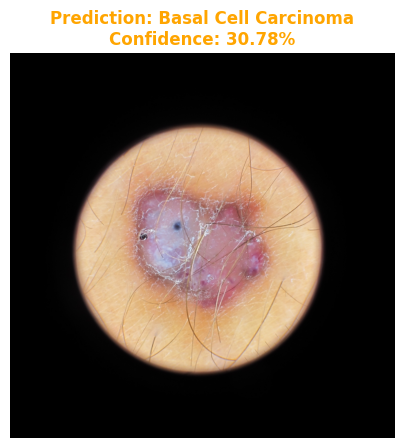

✅ Prediction Complete: Model classified image as 'Basal Cell Carcinoma' with 30.78% confidence.


In [25]:
TARGET_IMAGE = r"C:\Users\iToop\Downloads\skin\VASC\ISIC_0072012.jpg" 

print("\n--> Running automated evaluation gateway...")
run_live_prediction(TARGET_IMAGE, model, image_transforms, class_names)

In [3]:
import os

print("📍 YOUR CURRENT WORKING DIRECTORY IS:")
print(os.getcwd())
print("\n📦 FILES CURRENTLY SAVED IN THIS FOLDER:")
for file in os.listdir('.'):
    if file.endswith('.pth') or file.endswith('.h5') or file.endswith('.ipynb'):
        print(f" -> {file}")

📍 YOUR CURRENT WORKING DIRECTORY IS:
c:\Users\iToop\source\vsc\sdds\SDDS\prediction_app

📦 FILES CURRENTLY SAVED IN THIS FOLDER:
 -> skin_cancer_cnn.pth
 -> skin_cancer_model.h5.ipynb
